# 06 - Feature Engineering

**Milestone 1 — Part 5**: Investigate transformations to better expose data patterns.

## Objectives
- Apply feature scaling (standardize / normalize)
- Try at least **3 transformations** (log, polynomial, ratios, etc.)
- Evaluate each using correlations, F-scores, or feature selection
- Write transformations as **reusable functions**

## Expected Outcomes
| Deliverable | Description |
|---|---|
| Scaling function | StandardScaler applied to numerical features |
| Transform 1 | e.g., log(sqft) — evaluated with correlation |
| Transform 2 | e.g., price_per_sqft ratio — evaluated with F-score |
| Transform 3 | e.g., polynomial bedroom*bathroom — evaluated |
| Comparison table | Before vs after correlation/F-score for each |

## Key Rule (from assignment)
> Write transformations as functions. Don't commit yet — models may respond differently.

---

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_regression

RANDOM_STATE = 42
TARGET = "taxvaluedollarcnt"

df = pd.read_csv("zillow_cleaned.csv")
df_experiment = pd.read_csv("zillow_dataset.csv")
print(f"Shape: {df.shape}")

def dollar_format(x, pos):
    return f'${x:,.0f}'

Shape: (75894, 29)


## Helper: Evaluate a new feature's relationship with the target

In [2]:
def evaluate_feature(dataframe: pd.DataFrame, feature_name: str, target: str = TARGET):
    """Print correlation and F-score for a single feature vs target."""
    corr = dataframe[[feature_name, target]].corr().iloc[0, 1]
    f_score, p_val = f_regression(dataframe[[feature_name]], dataframe[target])
    print(f"  {feature_name:40s}  corr={corr:+.4f}   F={f_score[0]:12.1f}   p={p_val[0]:.2e}")
    return {"feature": feature_name, "corr": corr, "f_score": f_score[0], "p_value": p_val[0]}

## 1. Feature Scaling

In [ ]:
def scale_features(dataframe: pd.DataFrame, exclude_cols: list = None) -> pd.DataFrame:
    """Standardize numerical features (zero mean, unit variance)."""
    if exclude_cols is None:
        exclude_cols = []
    num_cols = [c for c in dataframe.select_dtypes(include=[np.number]).columns if c not in exclude_cols]
    scaler = StandardScaler()
    result = dataframe.copy()
    result[num_cols] = scaler.fit_transform(result[num_cols])
    return result, scaler

df_scaled, scaler = scale_features(df, exclude_cols=[TARGET])
print("Scaling complete. Sample means (should be ~0):")
print(df_scaled.drop(columns=[TARGET]).mean().head(5))

## 2. Transformation 1 — Log Transform

Applying `log1p` to right-skewed area/size features to reduce skew and potentially improve linear correlation.

In [ ]:
def add_log_features(dataframe: pd.DataFrame, columns: list) -> pd.DataFrame:
    """Add log1p-transformed versions of specified columns."""
    result = dataframe.copy()
    for col in columns:
        if col in result.columns:
            result[f"log_{col}"] = np.log1p(result[col].clip(lower=0))
    return result

# TODO: Adjust column list based on skewed features from notebook 02
log_cols = ["calculatedfinishedsquarefeet", "lotsizesquarefeet", "taxvaluedollarcnt"]
df_eng = add_log_features(df, log_cols)

print("Before vs After log transform:")
for col in log_cols:
    if col != TARGET:
        evaluate_feature(df, col)
        evaluate_feature(df_eng, f"log_{col}")

## 3. Transformation 2 — Ratio Features

Ratios can capture per-unit relationships that raw features miss.

In [3]:
def add_ratio_features(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Add ratio-based engineered features."""
    result = dataframe.copy()
    if "calculatedfinishedsquarefeet" in result.columns and "lotsizesquarefeet" in result.columns:
        result["living_to_lot_ratio"] = (
            result["calculatedfinishedsquarefeet"] / result["lotsizesquarefeet"].replace(0, np.nan)
        ).fillna(0)

    if "bathroomcnt" in result.columns and "bedroomcnt" in result.columns:
        result["bath_per_bedroom"] = (
            result["bathroomcnt"] / result["bedroomcnt"].replace(0, np.nan)
        ).fillna(0)

    # TODO: Add more ratios that make business sense
    return result

df_eng = add_ratio_features(df_eng)

print("Ratio feature evaluation:")
for feat in ["living_to_lot_ratio", "bath_per_bedroom"]:
    if feat in df_eng.columns:
        evaluate_feature(df_eng, feat)

NameError: name 'df_eng' is not defined

## 4. Transformation 3 — Polynomial / Interaction Features

Multiplying or squaring features to capture nonlinear relationships.

In [4]:
def add_polynomial_features(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Add polynomial and interaction features."""
    result = dataframe.copy()

    if "calculatedfinishedsquarefeet" in result.columns:
        result["sqft_squared"] = result["calculatedfinishedsquarefeet"] ** 2

    if "bathroomcnt" in result.columns and "bedroomcnt" in result.columns:
        result["bath_x_bed"] = result["bathroomcnt"] * result["bedroomcnt"]

    # TODO: Add more interactions based on domain knowledge
    return result

df_eng = add_polynomial_features(df_eng)

print("Polynomial feature evaluation:")
for feat in ["sqft_squared", "bath_x_bed"]:
    if feat in df_eng.columns:
        evaluate_feature(df_eng, feat)

NameError: name 'df_eng' is not defined

## 5. Comparison Summary

In [5]:
# Collect all new features for a side-by-side comparison
new_features = [
    col for col in df_eng.columns
    if col not in df.columns and col != TARGET
]

results = []
print(f"{'Feature':40s}  {'Corr':>8s}  {'F-Score':>12s}  {'p-value':>10s}")
print("-" * 75)
for feat in new_features:
    results.append(evaluate_feature(df_eng, feat))

results_df = pd.DataFrame(results).sort_values("f_score", ascending=False)
results_df

NameError: name 'df_eng' is not defined

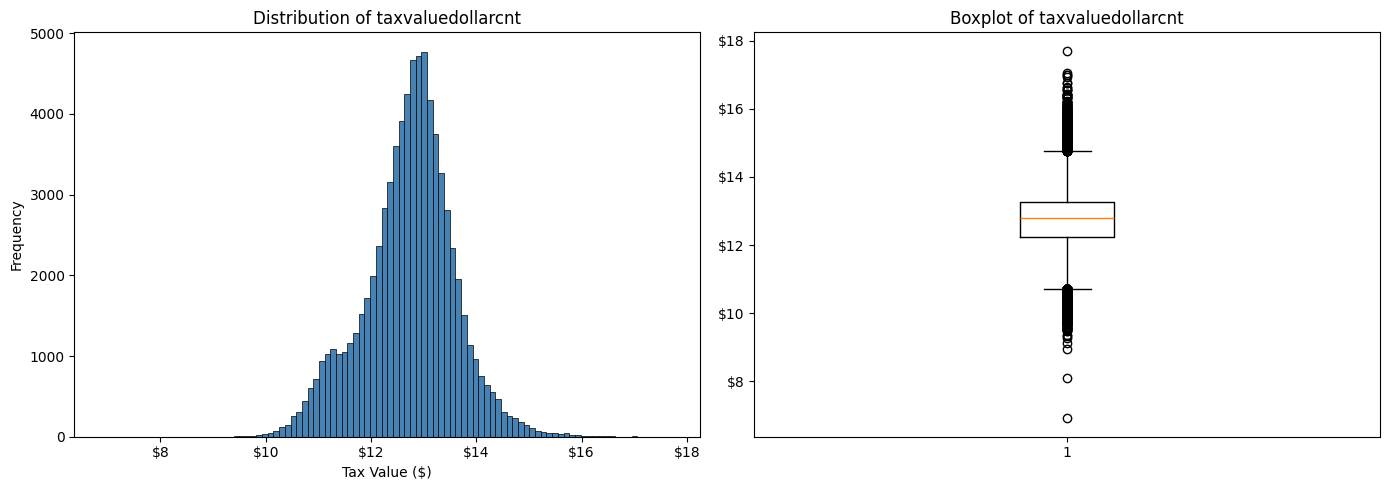

count    75859.000000
mean        12.722251
std          0.868416
min          6.907755
25%         12.240182
50%         12.791014
75%         13.252430
max         17.708580
Name: taxvaluedollarcnt, dtype: float64


In [13]:
#transformation 1: log transform
target = "taxvaluedollarcnt"


df_log = df.copy()
df_log[target] = np.log(df_experiment[target])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_log[target].dropna(), bins=100, edgecolor='black', linewidth=0.5, color='steelblue')
axes[0].set_title(f"Distribution of {target}")
axes[0].set_xlabel("Tax Value ($)")
axes[0].set_ylabel("Frequency")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

# Boxplot
axes[1].boxplot(df_log[target].dropna(), vert=True)
axes[1].set_title(f"Boxplot of {target}")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

plt.tight_layout()
plt.show()

print(df_log[target].describe())

#it looks like we can avoid any serious outlier removal by using the log transform, which is good because we don't want to lose data. 
# We can still consider capping extreme outliers if needed

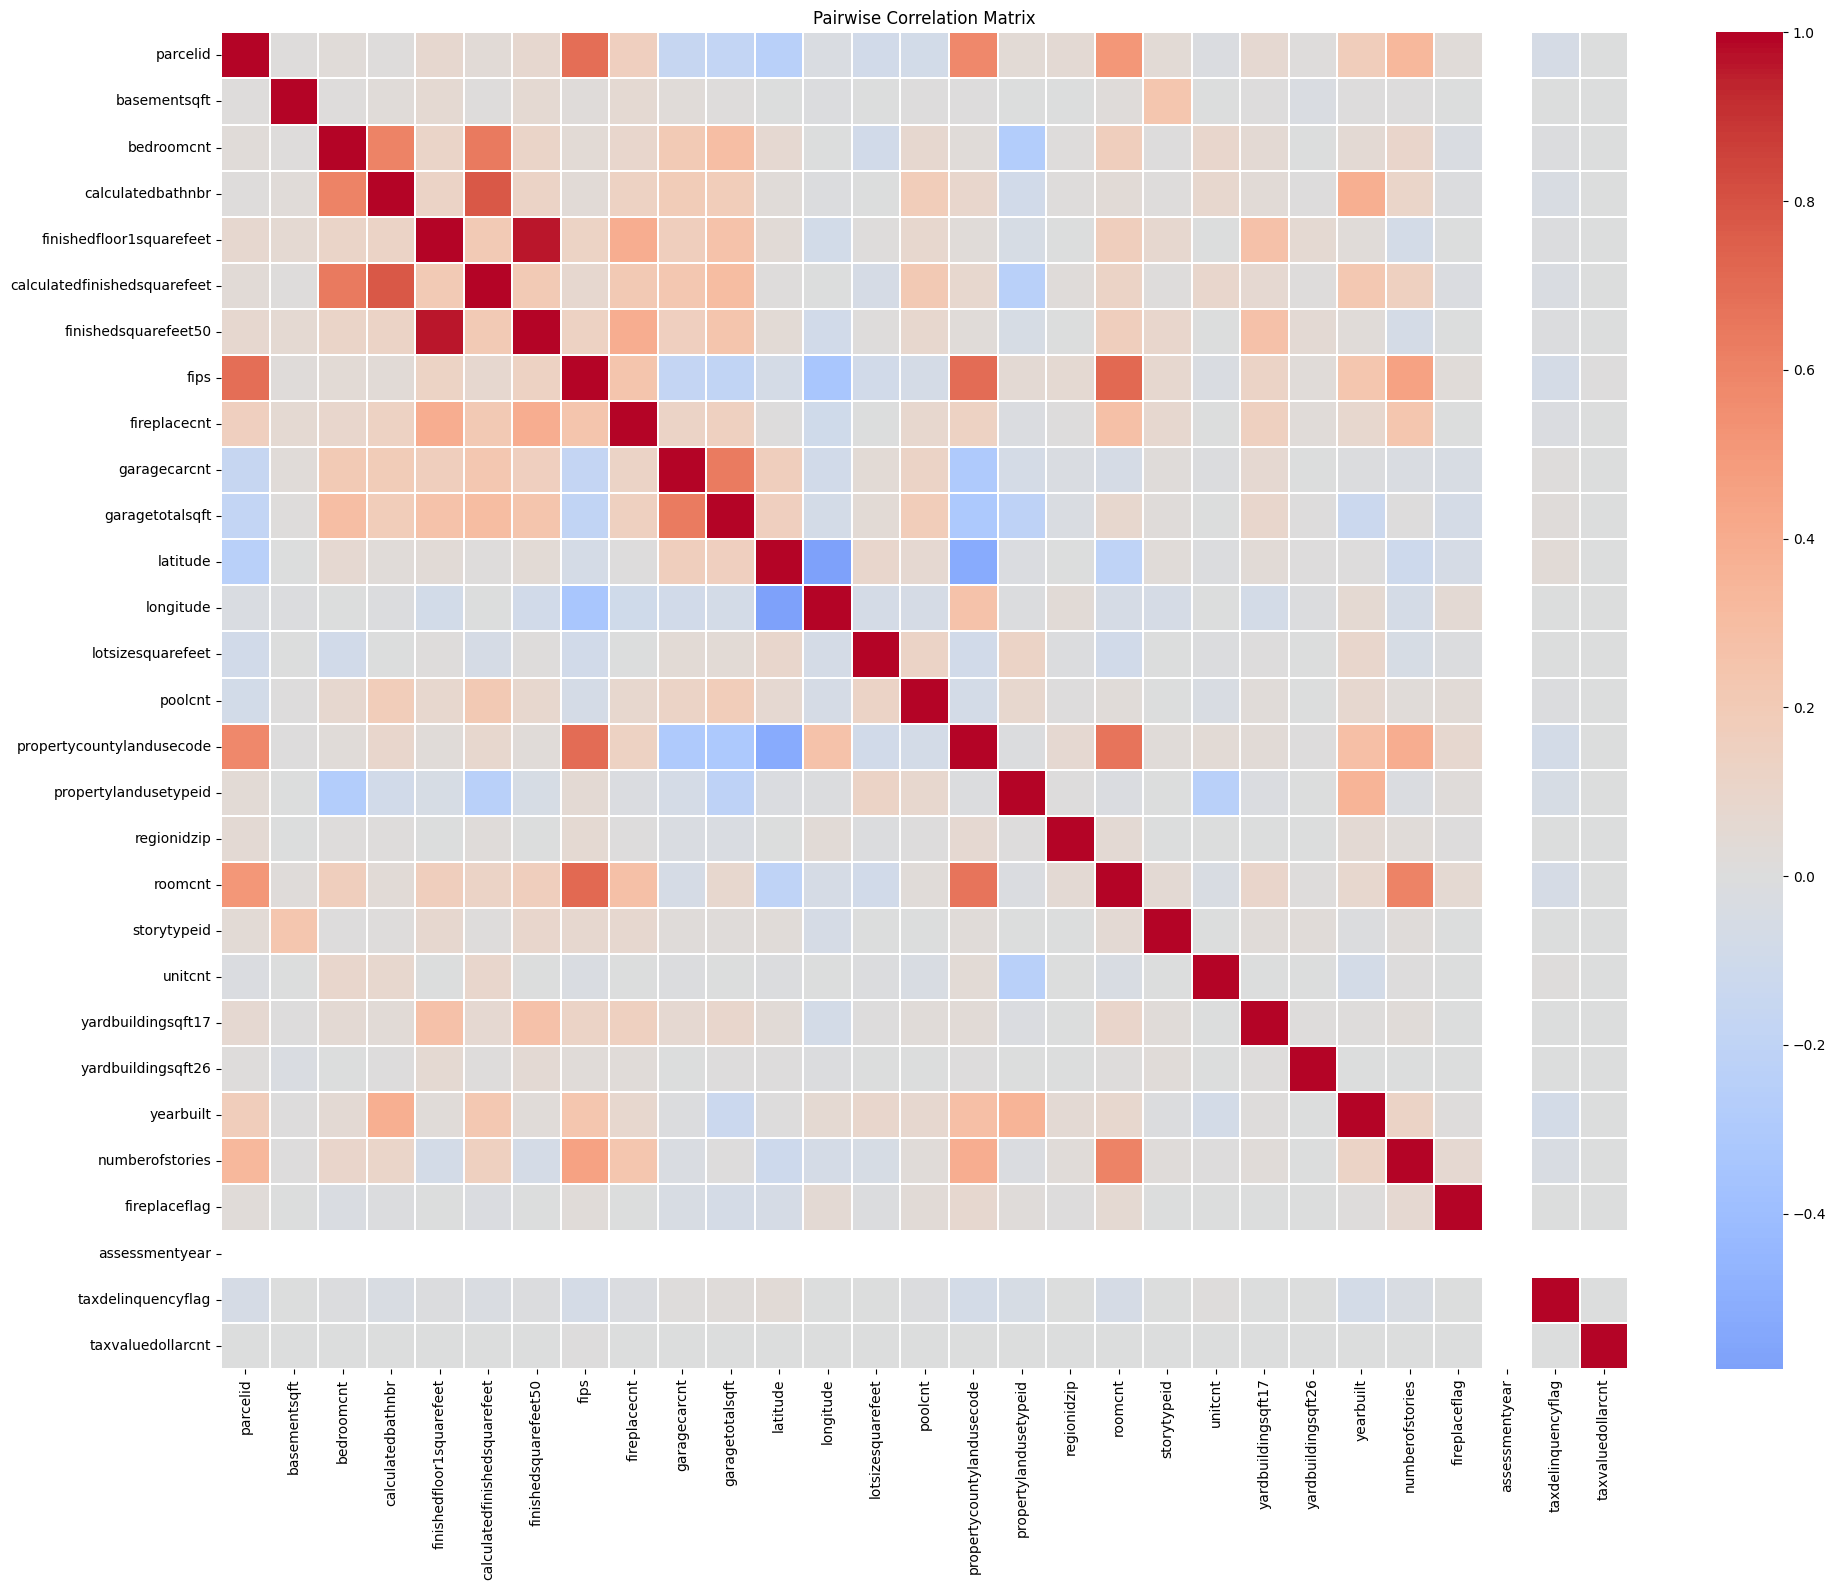

In [14]:
corr_matrix = df_log.corr(numeric_only=True)

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Pairwise Correlation Matrix")
plt.tight_layout()
plt.show()

In [10]:
#transformation 2: zip code target encoding

zip_means = df.groupby('regionidzip')['taxvaluedollarcnt'].mean() ## calculate mean target value for each zip code

print(zip_means.head()) 
print(zip_means.describe()) 

df_zip = df.copy()

df_zip['zip_mean_target'] = df_zip['regionidzip'].map(zip_means) ## map the mean target value for each zip code back to the original dataframe

df_zip['zip_bin'] = pd.qcut(df_zip['zip_mean_target'], q=5, labels=False) ## create 5 quantile-based bins for the zip code mean target values

print(df_zip[['regionidzip', 'zip_mean_target', 'zip_bin']].head()) 

regionidzip
95982.0    198804.161290
95983.0    205152.937500
95984.0    237151.120833
95985.0    653573.117647
95986.0    556462.538462
Name: taxvaluedollarcnt, dtype: float64
count    3.890000e+02
mean     4.392679e+05
std      2.090445e+05
min      4.594750e+04
25%      2.837878e+05
50%      3.804392e+05
75%      5.522626e+05
max      1.323916e+06
Name: taxvaluedollarcnt, dtype: float64
   regionidzip  zip_mean_target  zip_bin
0      96978.0    961955.959877        4
1      97099.0    522034.010870        3
2      97078.0    621411.757511        4
3      96330.0    441287.256809        3
4      96451.0    262256.307692        0


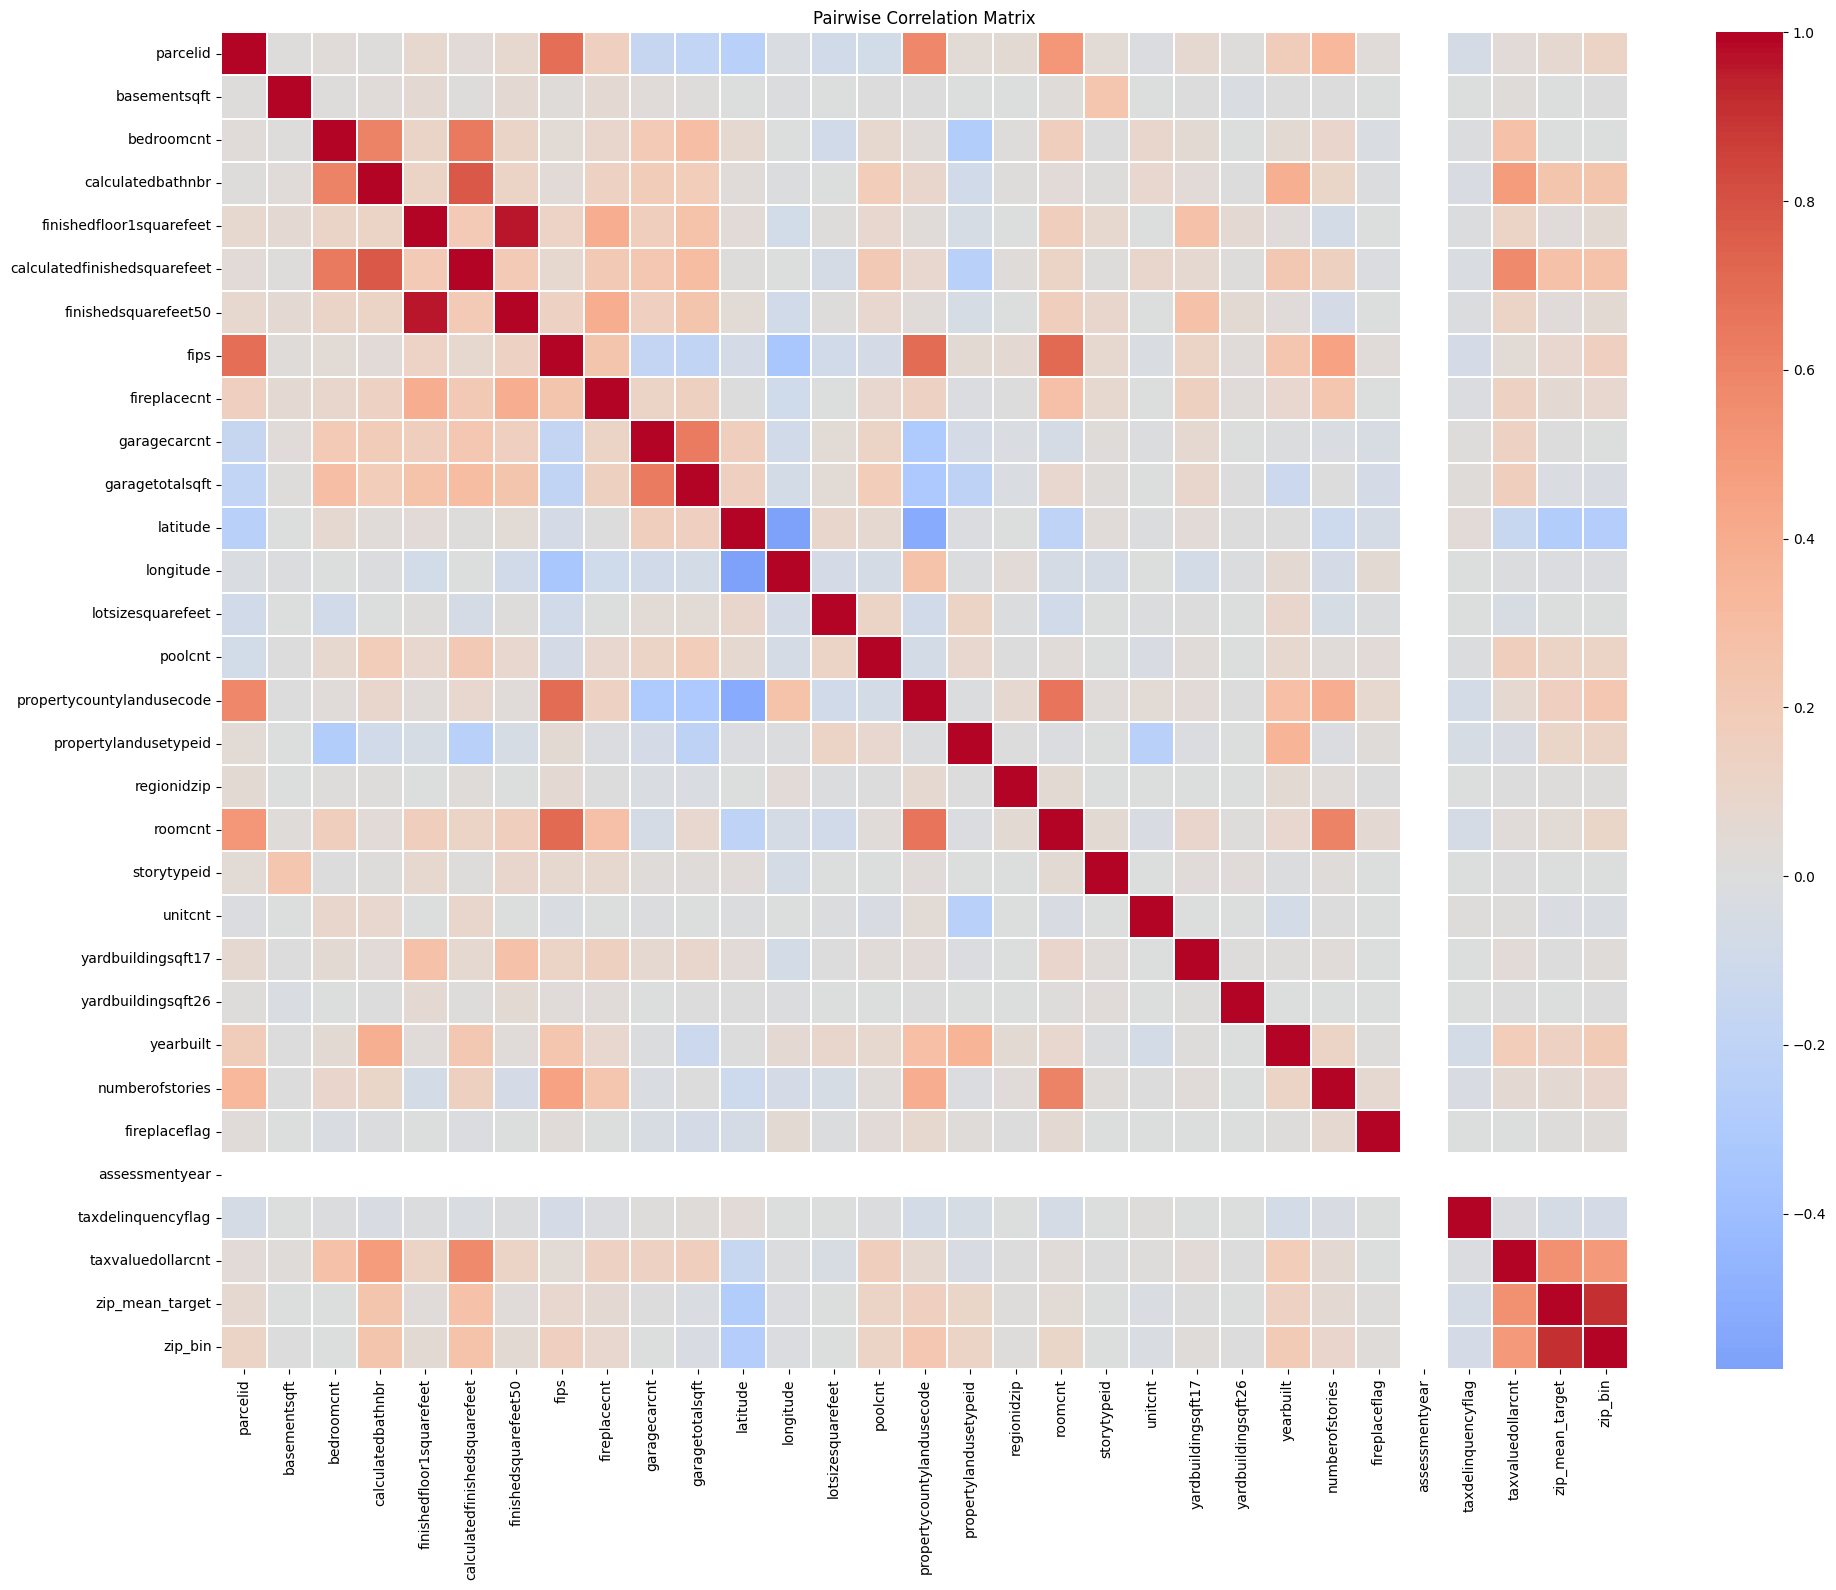

In [11]:
corr_matrix = df_zip.corr(numeric_only=True)

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Pairwise Correlation Matrix")
plt.tight_layout()
plt.show()

---
## Discussion 5

Describe why you chose these transformations and what you observed:
- Which transformations improved correlation / F-score?
- Which didn't help?
- What would you recommend carrying forward to modeling?

*YOUR ANSWER HERE*

---
### Next Notebook → `07_executive_summary.ipynb`